# Overview of Biophysical Neuronal Modelling with MOOSE

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import moose

INFO:numexpr.utils:NumExpr defaulting to 12 threads.


## The neuron as an electrical circuit
- Lipid bilayer = capacitor ($C_{m}$ at $1 \mu F / cm^{2}$)
- Leak channel = conductance ($G_{L}$, its inverse is membrane resistance $R_{m} = \frac{1}{G_{L}}$) in parallel 
- Equilibrium potential $E_{m}$ in series with $R_{m}$

![A passive neuronal compartment](https://moose.ncbs.res.in/readthedocs/_images/neuronalcompartment.jpg)

## The membrane equation
$C_{m}\frac{dV}{dt} = - \frac{V - E_{m}}{R_{m}} + I_{inject}$

The membrane voltage is getting pulled back to baseline at a rate proportional to how far it has strayed

This is the basic model `moose.Compartment` class implements.

In [2]:
# Create a container for the model - this is like a folder
model = moose.Neutral('/model')

# Create a neuronal compartment inside /model
soma = moose.Compartment('/model/soma')

### Aside: We can see the properties of the compartment using `moose.showfield`

In [5]:
moose.showfield(soma)


[/model[0]/soma[0]]
name          = soma
className     = Compartment
tick          = 3
dt            = 5e-05
Cm            = 1e-07
Em            = -0.065
Im            = 0.0
Ra            = 1.0
Rm            = 10000.0
Vm            = -0.06
diameter      = 0.0
initVm        = -0.065
inject        = 0.0
length        = 0.0
x             = 0.0
x0            = 0.0
y             = 0.0
y0            = 0.0
z             = 0.0
z0            = 0.0



### Set the passive properties Rm, Cm, and Em

In [4]:
soma.Em = -65e-3      # -65 mV
soma.initVm = -65e-3  # -65 mV
soma.Cm = 1e-7        # 100 nF
soma.Rm = 1e4         # 10 kOhm

### Add a current source to inject a current pulse

In [6]:
pg = moose.PulseGen('/model/pulse')
moose.connect(pg, 'output', soma, 'injectMsg')

<moose.SingleMsg path=/Msgs[0]/singleMsg[0] id=5 dataIndex=0 fieldIndex=0>

### Setup voltage and current recording

In [7]:
vm_tab = moose.Table('/model/Vm')
moose.connect(vm_tab, 'requestOut', soma, 'getVm')
im_tab = moose.Table('/model/Im')
moose.connect(im_tab, 'requestOut', soma, 'getIm')

<moose.SingleMsg path=/Msgs[0]/singleMsg[2] id=5 dataIndex=2 fieldIndex=0>

### Setup the current injection protocol

In [20]:
pg.firstDelay = 10e-3    # start current injection at 10 ms
pg.firstWidth = 20e-3     # inject the current forever
pg.firstLevel = 1e-6     # the amount of current is 1 uA 
pg.secondDelay =1e9

### Initialize and run the model for 10 ms

In [21]:
moose.reinit()

simtime = 50e-3

moose.start(simtime)

Text(0.5, 0, 'Time (ms)')

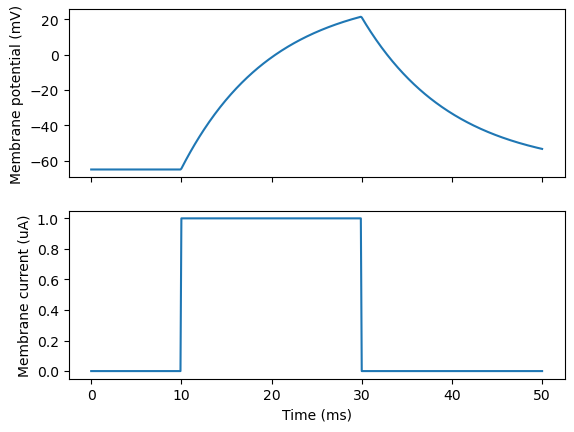

In [22]:
t = np.linspace(0, simtime, len(vm_tab.vector))
vm = vm_tab.vector
im = im_tab.vector

fig, axes = plt.subplots(nrows=2, ncols=1, sharex='all')

axes[0].plot(t * 1e3, vm * 1e3)
axes[0].set_ylabel('Membrane potential (mV)')
axes[1].plot(t * 1e3, im * 1e6)
axes[1].set_ylabel('Membrane current (uA)')
axes[1].set_xlabel('Time (ms)')             

### Exercise: Change the Rm and plot

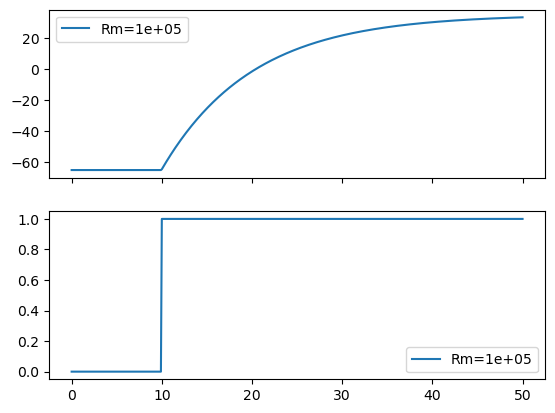

In [16]:
soma.Rm = 1e5    # 1 kOhm

moose.reinit()

moose.start(simtime)
t = np.linspace(0, simtime, len(vm_tab.vector))
vm = vm_tab.vector
im = im_tab.vector

fig, axes = plt.subplots(nrows=2, ncols=1, sharex='all')
axes[0].plot(t * 1e3, vm * 1e3, label=f'Rm={soma.Rm:0.2g}')
axes[1].plot(t * 1e3, im * 1e6, label=f'Rm={soma.Rm:0.2g}')
axes[0].legend()
axes[1].legend()


### Exercise: Plot multiple runs together

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=1, sharex='all')

simtime = 50e-3
for Rm in [0.5e4, 1e4, 2e4, 4e4]:
    soma.Rm = Rm
    moose.reinit()

    moose.start(simtime)
    t = np.linspace(0, simtime, len(vm_tab.vector))
    vm = vm_tab.vector
    im = im_tab.vector
    
    axes[0].plot(t * 1e3, vm * 1e3, label=f'Rm={soma.Rm:0.2g}')
    axes[1].plot(t * 1e3, im * 1e6, label=f'Rm={soma.Rm:0.2g}')
    
axes[0].legend()
axes[1].legend()


## Active neuron with ion channels

Hodgkin and Huxley figured out how $Na^{+}$ and $K^{+}$ ion-channels give rise to action potentials in a neuron.

These channels act as voltage-dependent conductances. The equivalent circuit of the neuronal compartment becomes:

 [<img src="HH_equivalent_circuit.svg" width="250"/>](HH_equivalent_circuit.svg)


$G_{Na}$ is the conductance of the $Na^{+}$ channel, and it depends on the membrane voltage.

$E_{Na}$ is the reversal potential of $Na^{+}$ ion according to Nernst equations.

$G_{K}$ is the conductance of the $K^{+}$ channel, and it also depends on the membrane voltage.
 
$E_{K}$ is the reversal potential of $K^{+}$ ion.

Now the membrane equation becomes

$C_{m} \frac{dV}{dt} = - G_{L} (V_{m} - E_{m}) - G_{Na} (V_{m} - E_{Na}) - G_{K} (V_{m} - E_{K}) + I_{inject}$

Hodgkin and Huxley suggested two gating variable $m$ and $h$ determining the total conductance of the $Na^{+}$ channel: 

$G_{Na} = \bar{G}_{Na} m^{3} h$


and one gating variable $n$ determining the total conductance of the $K^{+}$ channel:

$G_{K} = \bar{G}_{K} n^{4}$


Together:

$C_{m} \frac{dV}{dt} = - G_{L} (V_{m} - E_{m}) - \bar{G}_{Na} m^{3} h (V_{m} - E_{Na}) - \bar{G}_{K} n^{4} (V_{m} - E_{K}) + I_{inject}$

### Adding Na+ and K+ channels to our passive compartment

`moose.HHChannel` class implements Hodgkin-Huxley-type ion channels. It has three generic gating variables, 'X', 'Y', and 'Z'. We only need 'X' and 'Y' here.

In [23]:
EREST_ACT = -70e-3

# Create Na channel Na_HH
nachan = moose.HHChannel(f'{soma.path}/Na_HH')
moose.connect(nachan, 'channel', soma, 'channel')

nachan.Xpower = 3   # 3 m gates provide m^3
nachan.Ypower = 1   # 1 h gate

mgate = moose.element(f'{nachan.path}/gateX')
ngate = moose.element(f'{nachan.path}/gateY')

mgate.alphaExpr = (
        f'1e3 * 0.1 * (25 - 1e3 * (v - ({EREST_ACT}))) /'
        f'(exp((25 - 1e3 * (v - ({EREST_ACT}))) / 10) - 1)'
    )
mgate.betaExpr = f'1e3 * 4 * exp(- (v - ({EREST_ACT}))/ 18e-3)'

hgate = moose.element(f'{nachan.path}/gateY')

hgate.alphaExpr = f'1e3 * 0.07 * exp(- 1e3 * (v - ({EREST_ACT}))/ 20)'
hgate.betaExpr = f'1e3 / (exp((30 - 1e3 * (v - ({EREST_ACT}))) / 10) + 1)'

# Create K channel K_HH and connect it to the compartment
kchan = moose.HHChannel(f'{soma.path}/K_HH')
moose.connect(kchan, 'channel', soma, 'channel')


kchan.Xpower = 4    # Gbar is multiplied by 4-th power of n: Gbar_K * n^4 

ngate = moose.element(f'{kchan.path}/gateX')

ngate.alphaExpr = (
        f'1e3 * 0.01 * (10 - 1e3 * (v - ({EREST_ACT}))) /'
        f'(exp((10 - 1e3 * (v - ({EREST_ACT})))/10) - 1)'
    )
ngate.betaExpr = f'1e3 * 0.125 * exp(-1e3 * (v - ({EREST_ACT})) / 80)'

for g in (mgate, hgate, ngate):
    g.divs = 150
    g.min = -100e-3
    g.max = 120e-3

nachan.Ek = 115e-3 + EREST_ACT
kchan.Ek = -12e-3 + EREST_ACT


# Gbar is maximum conductance. 
# The voltage dependent conductance value is computed and 
# stored in the field Gk
sarea = soma.Cm / 0.01
soma.Em = EREST_ACT + 10.613e-3
soma.initVm = soma.Em
soma.Rm = 1 / (0.3e-3 * sarea * 1e4)
nachan.Gbar = 120e-3 * sarea * 1e4
kchan.Gbar = 36e-3 * sarea * 1e4

### Recording channel conductance

In [24]:
gNa_tab = moose.Table(f'{model.path}/gNa')
moose.connect(gNa_tab, 'requestOut', nachan, 'getGk')
gK_tab = moose.Table(f'{model.path}/gK')
moose.connect(gK_tab, 'requestOut', kchan, 'getGk')

<moose.SingleMsg path=/Msgs[0]/singleMsg[6] id=5 dataIndex=6 fieldIndex=0>

### Running simulation with changing current injection

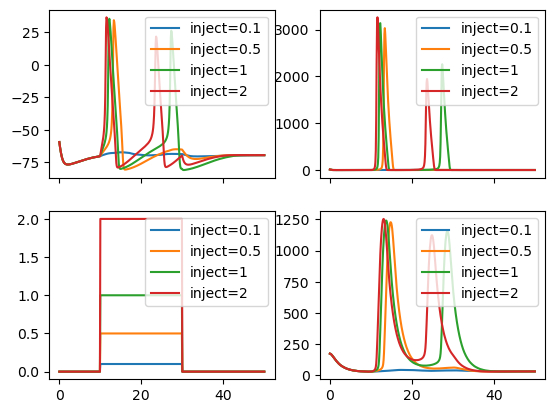

In [27]:
fig, axes = plt.subplots(nrows=2, ncols=2, sharex='all')

simtime = 50e-3
for inject in [0.1, 0.5, 1, 2]:
    pg.firstLevel = inject * 1e-6
    moose.reinit()

    moose.start(simtime)
    t = np.linspace(0, simtime, len(vm_tab.vector))
    vm = vm_tab.vector
    im = im_tab.vector
    
    axes[0, 0].plot(t * 1e3, vm * 1e3, label=f'inject={inject:0.2g}')
    axes[1, 0].plot(t * 1e3, im * 1e6, label=f'inject={inject:0.2g}')
    axes[0, 1].plot(t* 1e3, gNa_tab.vector * 1e6, label=f'inject={inject:0.2g}')
    axes[1, 1].plot(t* 1e3, gK_tab.vector * 1e6, label=f'inject={inject:0.2g}')

for ax in axes.flat:    
    ax.legend()